In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')

print(f"Shape of dataset: {df.shape[0]} rows and {df.shape[1]} columns\n")

print("=== Dataset Information ===")
print(df.info())

print("\n=== First 5 rows ===")
display(df.head())

print("\n=== Statistical Summary ===")
display(df.describe())


Shape of dataset: 299 rows and 13 columns

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1



=== Statistical Summary ===


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000



=== Missing Values ===
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

=== Duplicate Rows ===
Number of duplicate rows: 0

=== Target Variable Distribution (DEATH_EVENT) ===
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
Percentage of deaths: 32.11%


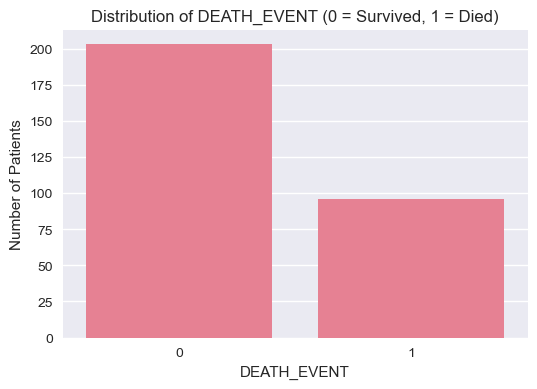

In [2]:
# find missing values, duplicates, and target variable distribution
print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n=== Target Variable Distribution (DEATH_EVENT) ===")
print(df['DEATH_EVENT'].value_counts())
print(f"Percentage of deaths: {df['DEATH_EVENT'].mean()*100:.2f}%")

# Plot target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='DEATH_EVENT')
plt.title('Distribution of DEATH_EVENT (0 = Survived, 1 = Died)')
plt.ylabel('Number of Patients')
plt.show()

In [3]:
# Feature Types 
numerical_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 
                  'platelets', 'serum_creatinine', 'serum_sodium', 'time']
binary_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

print(f"\nNumerical features: {numerical_cols}")
print(f"Binary features: {binary_cols}")


Numerical features: ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
Binary features: ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']


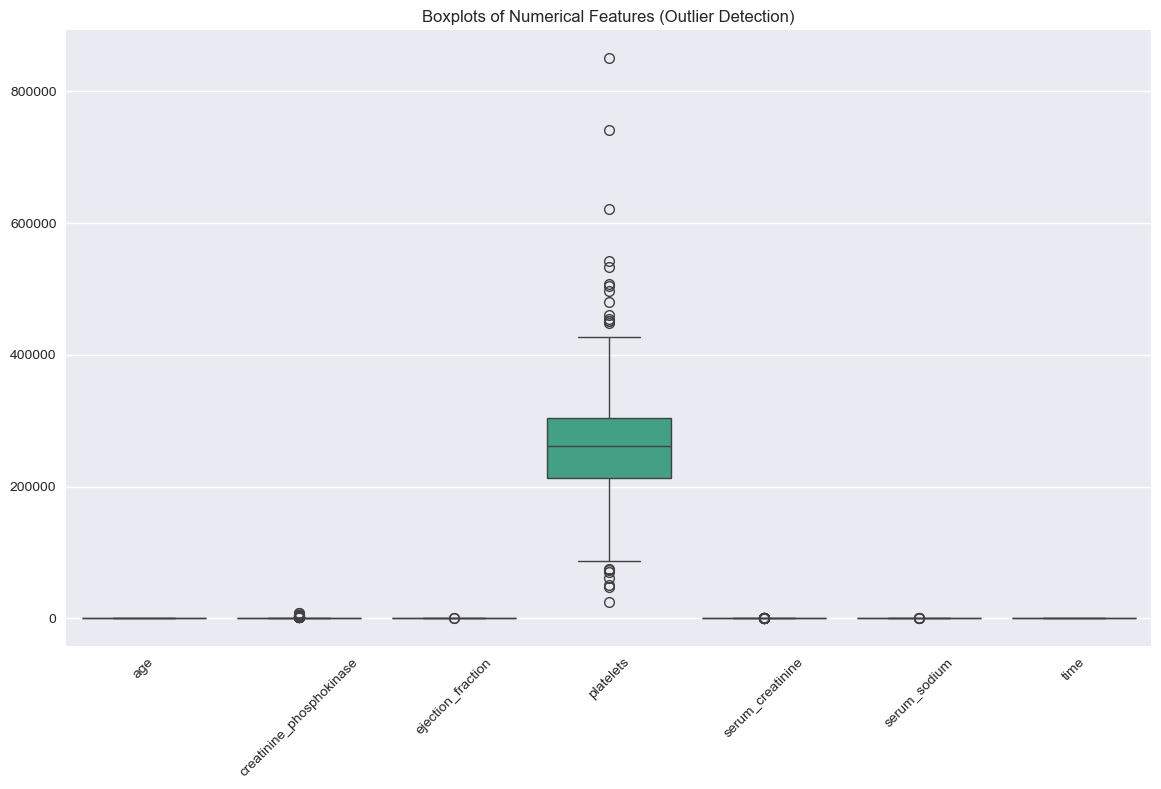

In [4]:
# Boxplots to detect outliers
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features (Outlier Detection)')
plt.show()

In [8]:
#Preprocessing - Final Cleaning

# Separate features and target (if not already done)
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# IMPORTANT: Drop 'time' column to prevent data leakage =
if 'time' in X.columns:
    X = X.drop('time', axis=1)
    print(" Dropped 'time' column to prevent data leakage.")

# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"After splitting:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled data back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(" Feature scaling completed using StandardScaler")

# Save Cleaned Data 
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

 Dropped 'time' column to prevent data leakage.
After splitting:
X_train shape: (239, 11)
X_test shape:  (60, 11)
 Feature scaling completed using StandardScaler
